# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np


In [113]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [114]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [115]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [116]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [117]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [118]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [119]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [120]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [121]:
# cantidad de nulos para users
city_nulls = users["city"].isna().sum()
churn_date_nulls = users["churn_date"].isna().sum()

print("Cantidad de valores nulos")
print("city nulos:", city_nulls)
print("churn date nulos:", churn_date_nulls)


# Proporción de valores nulos
city_nulls_prop = users["city"].isna().mean()
churn_date_nulls_prop = users["churn_date"].isna().mean()

print("Proporción de valores nulos")
print("city prop nulos:", city_nulls_prop)
print("churn prop nulos:", churn_date_nulls_prop)


Cantidad de valores nulos
city nulos: 469
churn date nulos: 3534
Proporción de valores nulos
city prop nulos: 0.11725
churn prop nulos: 0.8835


In [122]:
# cantidad de nulos para usage
date_nulls = usage["date"].isna().sum()
duration_nulls = usage["duration"].isna().sum()
length_nulls = usage["length"].isna().sum()

print("Cantidad de valores nulos")
print("Date nulos:", date_nulls)
print("Duration nulos:", duration_nulls)
print("Length nulos:", length_nulls)

# Proporción de val ores nulos
date_nulls_prop  = usage["date"].isna().mean()
duration_nulls_prop = usage["duration"].isna().mean()
length_nulls_prop = usage["length"].isna().mean()

print("Proporción de valores nulos")
print("Date prop nulos:", date_nulls_prop)
print("Duration prop nulos:", churn_date_nulls_prop)
print("Length nulos:", length_nulls_prop)

Cantidad de valores nulos
Date nulos: 50
Duration nulos: 22076
Length nulos: 17896
Proporción de valores nulos
Date prop nulos: 0.00125
Duration prop nulos: 0.8835
Length nulos: 0.4474


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En Users:
- Proporción de valores nulos
    city prop nulos: 0.11725
    churn prop nulos: 0.8835
  En Usage:
  Proporción de valores nulos
    Date prop nulos: 0.00125
    Duration prop nulos: 0.8835
    Length nulos: 0.4474

- Indica qué harías: ¿imputar, eliminar, ignorar?
- En Users:
- Churn_date (fecha de baja) es correcto que tenga gran porcentaje porcentaje nulo.
- En Usage:
- Duration y Length están relacionados con el tipo de uso: call or text. Cuando es call tiene duración y no longitud por el contario cuando es texto tiene longitud pero no duración Por lo cual ambas columnas se imputan.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [123]:
# explorar columnas numéricas de users

columnas_numericas = ["user_id", "age"]

users[columnas_numericas].describe()



,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


En Users:
- La columna `user_id` ... Los datos están completos.
- La columna `age` ... tiene en valor minimo -999.000000, lo cual es un error. Hay que corregirlo.

In [124]:
# explorar columnas numéricas de usage
columnas_numericas = ["id", "user_id", "duration", "length"]

usage[columnas_numericas].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
  
  Las columnas `id` y `user_id` son identificadores únicos por lo cual no deben modificarse.
- Las columnas "duration" y "length" como valor mínimo "0.000000", por lo cual habría que revisarlo.

In [125]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` ... en esta columna faltan datos, se contabilizaron 3531 de 4000. Hay que revisar que es lo que pasa.
- La columna `plan` ... en esta columna si estan todos los datos y nos indica que el plan top es el "Básico" con una frecuencia de 2595.

In [126]:
# explorar columna categórica de usage
usage['type'].describe()


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` ... nos indica que solo hay dos tipos y el top es "texto" con una frecuencia de 22092. No hay datos faltantes, ya que cuenta 40000.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En Users:
- La columna `user_id` ... son identificadores únicos por lo cual no deben modificarse.
- La columna `age` ... tiene en valor minimo -999.000000, lo cual es un error. Hay que corregirlo.
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [127]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [128]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [129]:
# Revisar los años presentes en `reg_date` de users
users['reg_date_year'] = users['reg_date'].dt.year
users['reg_date_year'].describe()


count    4000.000000
mean     2023.034000
std         0.866044
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2026.000000
Name: reg_date_year, dtype: float64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Están los años 2022 al 2026

In [130]:
# Revisar los años presentes en `date` de usage
usage['date_year'] = usage['date'].dt.year
usage['date_year'].describe()

count    39950.0
mean      2024.0
std          0.0
min       2024.0
25%       2024.0
50%       2024.0
75%       2024.0
max       2024.0
Name: date_year, dtype: float64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

En `date` solo aparece el año "2024"

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  En `reg_date`, Solo están los años del 2022 al 2026.
  En `date` solo aparece el año "2024"
- ¿Qué harías con ellas?
  Se ignora `reg_date` y solo se tomará `date`.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [131]:
# Reemplazar -999 por la mediana de age
users["age_mediana"] = pd.to_numeric(users["age"], errors="coerce")
users["age_mediana"] = users["age_mediana"].replace(-999, pd.NA)
users["age_mediana"] = users["age_mediana"].fillna(users["age_mediana"].median())

# Verificar cambios
users["age_mediana"].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age_mediana, dtype: float64

In [132]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", np.nan)

# Verificar cambios
users["city"].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [133]:
# Marcar fechas futuras como NA para reg_date

# 1. Convertir columna a tipo datetime
users["reg_date"] = pd.to_datetime(users["reg_date"])

# 2. Definir el límite máximo (fin de 2024)
limite_2024 = pd.Timestamp('2024-12-31')

# 3. Marcar como NA las fechas mayores al límite
users.loc[users["reg_date"] > limite_2024, 'fecha'] = pd.NA

# Verificar cambios
users["reg_date"].describe()


count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.
  Los nulos en `duration` y `length` son **MAR** debido a que depende de "type": Texto --> `length` y Call --> `duration`, por lo cual los nulos se justifican segun el tipo.


In [134]:
# Verificación MAR en usage (Missing At Random) para duration

type_texto = ((usage["type"] == "text") & (usage["duration"].isna())).sum()
print("Tipo texto", type_texto)


Tipo texto 22076


In [135]:
# Verificación MAR en usage (Missing At Random) para length

# tipo_llamada = ((usage["type"] == "call") & (usage["length"].isna())).count()
# print("Tipo llamada", tipo_llamada)

# 1. Definimos las dos condiciones
condicion_contiene_call = usage["type"].str.contains("call", case=False, na=False)
condicion_length_nulo = usage["length"].isna()

# 2. Combinamos con & y sumamos
total_llamadas_vacias = (condicion_contiene_call & condicion_length_nulo).sum()

print("Total de registros que contienen 'call' y tienen length vacío:", total_llamadas_vacias)

Total de registros que contienen 'call' y tienen length vacío: 17896


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se revisó la relación de tipo con duracion y length y son correctos los nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [136]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").size().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,0
0,10000,10
1,10001,15
2,10002,7


In [137]:
# Renombrar columnas

usage.rename(
    columns={
        "is_text": "cant_mensajes",
        "is_call": "cant_llamadas",
        "duration": "cant_minutos_llamada"
    }, 
    inplace=True
)

# Ahora puedes llamarlas con sus nuevos nombres
print(usage[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].head())

# observar resultado
usage_agg.head(3)

   cant_mensajes  cant_llamadas  cant_minutos_llamada
0              0              1                  0.09
1              1              0                   NaN
2              1              0                   NaN
3              0              1                  1.53
4              0              1                  4.84


,user_id,0
0,10000,10
1,10001,15
2,10002,7


In [138]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage, on="user_id", how="inner")
user_profile.head(15)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_year,age_mediana,fecha,id,type,date,cant_minutos_llamada,length,date_year,cant_mensajes,cant_llamadas
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,6274,text,2024-01-29 09:15:53.393834845,NaN,33.0,2024.0,1,0
1,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,11903,call,2024-02-23 20:35:22.253056326,7.40,NaN,2024.0,0,1
2,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,16251,text,2024-03-14 12:47:38.831470786,NaN,22.0,2024.0,1,0
3,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,16549,call,2024-03-15 21:09:27.824195604,5.84,NaN,2024.0,0,1
4,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,22139,call,2024-04-10 04:14:48.862221555,10.46,NaN,2024.0,0,1
5,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,24418,text,2024-04-20 11:45:08.977724442,NaN,36.0,2024.0,1,0
6,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,27202,text,2024-05-03 02:06:08.829220730,NaN,45.0,2024.0,1,0
7,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,35778,text,2024-06-10 21:28:45.613140328,NaN,46.0,2024.0,1,0
8,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,37579,text,2024-06-19 01:04:22.176554412,NaN,44.0,2024.0,1,0
9,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,38685,text,2024-06-24 01:11:14.746868670,NaN,32.0,2024.0,1,0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [139]:
# Resumen estadístico de las columnas numéricas

# 1. Obtiene el resumen estadístico básico (incluye media, mínimo, máximo, etc.)
resumen = usage.describe()

# 2. Mostramos el resumen en pantalla
print(resumen)

                id       user_id  cant_minutos_llamada        length  \
count  40000.00000  40000.000000          17924.000000  22104.000000   
mean   20000.50000  12002.405975              5.202237     52.127398   
std    11547.14972   1157.279564              6.842701     56.611183   
min        1.00000  10000.000000              0.000000      0.000000   
25%    10000.75000  10996.000000              1.437500     37.000000   
50%    20000.50000  12013.000000              3.500000     50.000000   
75%    30000.25000  13005.000000              6.990000     64.000000   
max    40000.00000  13999.000000            120.000000   1490.000000   

       date_year  cant_mensajes  cant_llamadas  
count    39950.0   40000.000000   40000.000000  
mean      2024.0       0.552300       0.447700  
std          0.0       0.497263       0.497263  
min       2024.0       0.000000       0.000000  
25%       2024.0       0.000000       0.000000  
50%       2024.0       1.000000       0.000000  
75%     

In [140]:
# Distribución porcentual del tipo de plan
distribucion_tipo_de_plan = user_profile["plan"].value_counts(normalize=True)
print(distribucion_tipo_de_plan)

Basico     0.647475
Premium    0.352525
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

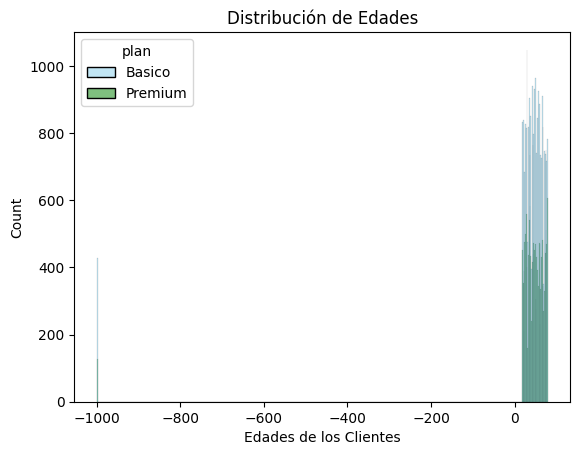

In [141]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x="age", hue='plan', palette=['skyblue','green'])
plt.xlabel("Edades de los Clientes")
plt.title("Distribución de Edades")
plt.show()


💡Insights: 
- Distribución ... En "age" hay outliers en el de -999

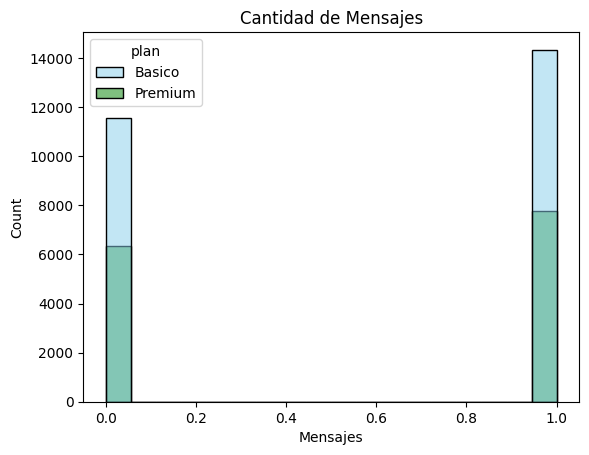

In [37]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue='plan', palette=['skyblue','green'])
plt.xlabel("Mensajes")
plt.title("Cantidad de Mensajes")
plt.show()


💡Insights: 
- Nos muestra la cantidad de mensajes en "1" y en "0" los que no son mensajes.

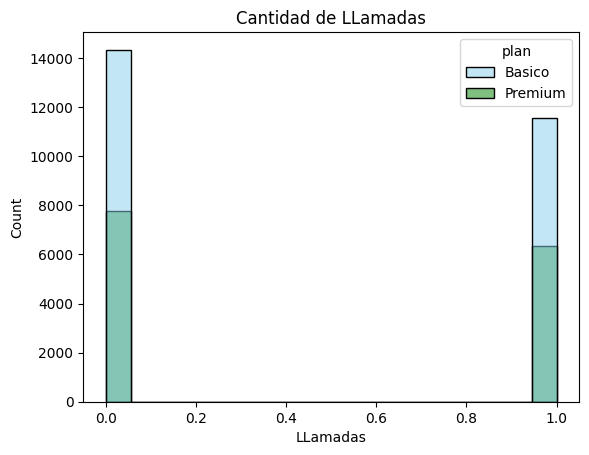

In [142]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue='plan', palette=['skyblue','green'])
plt.xlabel("LLamadas")
plt.title("Cantidad de LLamadas")
plt.show()


💡Insights: 
- Distribución ... Nos muestra la cantidad de llamadas en "1" y en "0" los que no son llamadas.

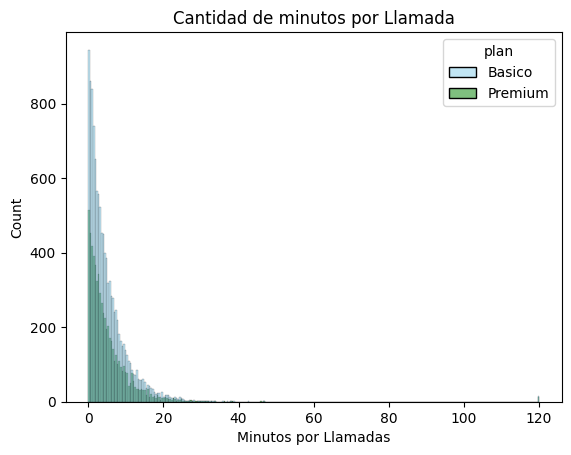

In [143]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x="cant_minutos_llamada", hue='plan', palette=['skyblue','green'])
plt.xlabel("Minutos por Llamadas")
plt.title("Cantidad de minutos por Llamada")
plt.show()


💡Insights: 
- Nos muestra que hay llamadas de "larga duración" sospechosas. HAy que revisar si son válidas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

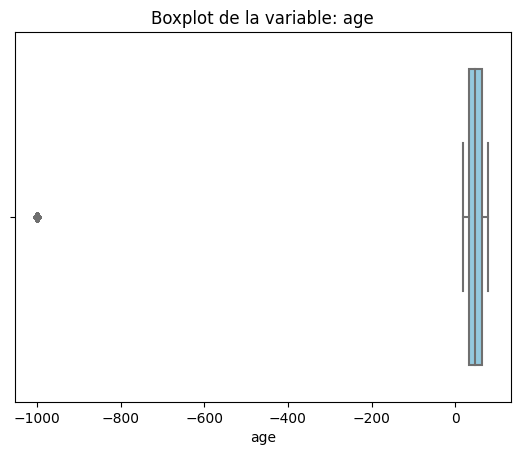

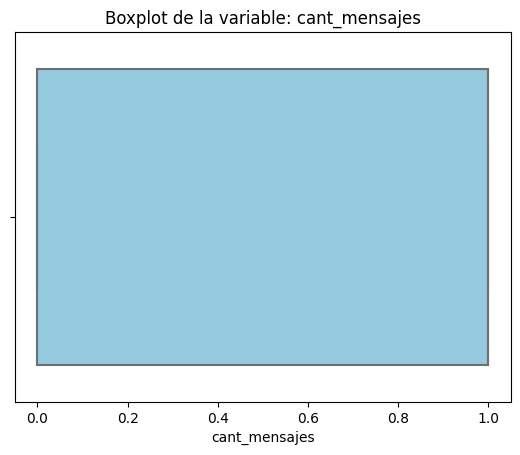

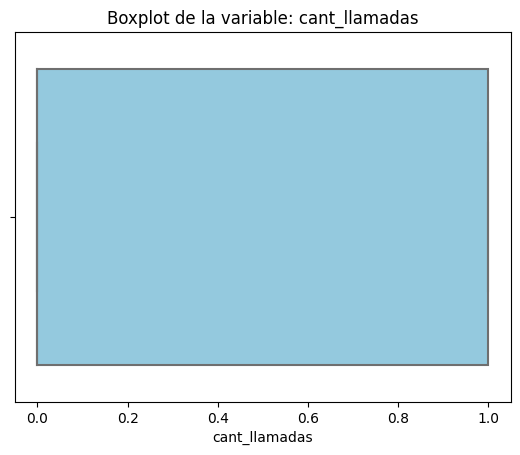

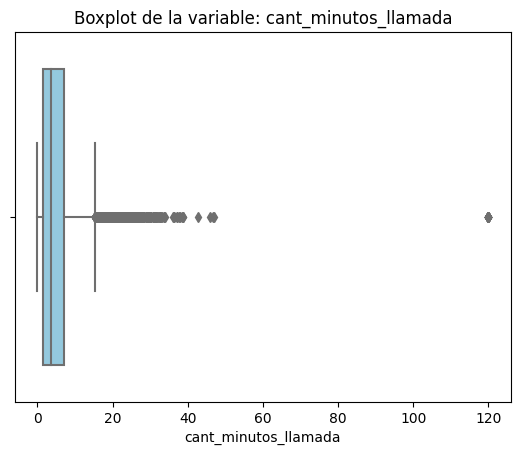

In [144]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

def crear_boxplot(columnas):
    for col in columnas:
                
        # Sintaxis limpia de Seaborn
        sns.boxplot(data=user_profile, x=col, color='skyblue')
        
        plt.title(f'Boxplot de la variable: {col}')
        plt.xlabel(col)
        
        # Mostramos CADA gráfico antes de avanzar en el bucle
        plt.show()

# Llamamos a la función
crear_boxplot(columnas_numericas)



💡Insights: 
- Age: ...(presenta o no outliers) Si presenta outliers
- cant_mensajes: ... No presenta outliers
- cant_llamadas: ... No presenta outliers
- cant_minutos_llamada: ... Si presenta outliers

In [145]:
# Calcular límites con el método IQR
columnas_limites = ["age", "cant_minutos_llamada"]

def limites_iqr(columnas):
    for col in columnas:
        # calcular Q1, Q3 e IQR
        Q1 = user_profile[col].quantile(0.25)
        Q3 = user_profile[col].quantile(0.75)
        IQR = IQR = Q3 - Q1
        
        # Mostrar resultados
        print(col)
        print('Primer cuartil: ', Q1)
        print('Tercer cuartil: ', Q3)
        print('IQR: ', IQR)

# Llamamos a la función
limites_iqr(columnas_limites)


age
Primer cuartil:  32.0
Tercer cuartil:  63.0
IQR:  31.0
cant_minutos_llamada
Primer cuartil:  1.4375
Tercer cuartil:  6.99
IQR:  5.5525


In [146]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_minutos_llamada
count,40000.000000,17924.000000
mean,33.622125,5.202237
std,123.755774,6.842701
min,-999.000000,0.000000
25%,32.000000,1.437500
50%,48.000000,3.500000
75%,63.000000,6.990000
max,79.000000,120.000000


💡Insights: 
- Age: No se mantienen.
- cant_mensajes: mantener o no outliers, porqué? Se mantienen, no son outliers.
- cant_llamadas: mantener o no outliers, porqué? Se mantienen, no son outliers.
- cant_minutos_llamada: mantener o no outliers, porqué? No se mantienen.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [147]:
# PASO 1: Agrupar FUERA de la función para calcular los totales de cada usuario una sola vez
user_totals = user_profile.groupby("user_id")[["cant_llamadas", "cant_mensajes"]].sum().reset_index()

# Opcional: Si quieres ver los totales generales antes de clasificar
print("Llamadas totales por usuario:\n", user_totals[["user_id", "cant_llamadas"]])
print("Mensajes totales por usuario:\n", user_totals[["user_id", "cant_mensajes"]])

# PASO 2: La función ahora solo recibe la FILA (row) con los totales de UN usuario a la vez
def classify_uso(row):
    # Extraemos los números individuales de la fila actual
    llamadas = row["cant_llamadas"]
    mensajes = row["cant_mensajes"]

    # Evaluamos con los 'if' tradicionales (ahora sí son números individuales)
    if (llamadas < 5) and (mensajes < 5):
        return "Bajo uso"
    elif (llamadas < 10) and (mensajes < 10):
        return "Uso medio"
    else: 
        return "Alto uso"

# PASO 3: Aplicamos la función sobre nuestra tabla de totales agrupados
user_totals["grupo_uso"] = user_totals.apply(classify_uso, axis=1)

# PASO 4: Unimos la clasificación de vuelta a tu tabla 'user_profile' original
user_profile = user_profile.merge(user_totals[["user_id", "grupo_uso"]], on="user_id", how="left")



Llamadas totales por usuario:
       user_id  cant_llamadas
0       10000              3
1       10001             10
2       10002              2
3       10003              3
4       10004              3
...       ...            ...
3994    13995              3
3995    13996              3
3996    13997              3
3997    13998              6
3998    13999              6

[3999 rows x 2 columns]
Mensajes totales por usuario:
       user_id  cant_mensajes
0       10000              7
1       10001              5
2       10002              5
3       10003             11
4       10004              4
...       ...            ...
3994    13995              6
3995    13996              4
3996    13997              5
3997    13998              6
3998    13999              3

[3999 rows x 2 columns]


In [148]:
# verificar cambios
user_profile.head(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_year,age_mediana,fecha,id,type,date,cant_minutos_llamada,length,date_year,cant_mensajes,cant_llamadas,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,6274,text,2024-01-29 09:15:53.393834845,NaN,33.0,2024.0,1,0,Uso medio
1,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,11903,call,2024-02-23 20:35:22.253056326,7.40,NaN,2024.0,0,1,Uso medio
2,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,16251,text,2024-03-14 12:47:38.831470786,NaN,22.0,2024.0,1,0,Uso medio
3,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,16549,call,2024-03-15 21:09:27.824195604,5.84,NaN,2024.0,0,1,Uso medio
4,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,22139,call,2024-04-10 04:14:48.862221555,10.46,NaN,2024.0,0,1,Uso medio
5,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,24418,text,2024-04-20 11:45:08.977724442,NaN,36.0,2024.0,1,0,Uso medio
6,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,27202,text,2024-05-03 02:06:08.829220730,NaN,45.0,2024.0,1,0,Uso medio
7,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,35778,text,2024-06-10 21:28:45.613140328,NaN,46.0,2024.0,1,0,Uso medio
8,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,37579,text,2024-06-19 01:04:22.176554412,NaN,44.0,2024.0,1,0,Uso medio
9,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,NaN,38685,text,2024-06-24 01:11:14.746868670,NaN,32.0,2024.0,1,0,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [149]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = 0

def classify_edad(row):
    # 1. Segmentación por grupo_edad
    edad = row["age"]

    if edad < 30:
        return "Joven"
    
    elif edad < 60:
        return "Adulto"
    
    else:
         return "Adulto Mayor"

# 2. Aplicar la función fila por fila (axis=1) para crear y rellenar la columna
user_profile["grupo_edad"] = user_profile.apply(classify_edad, axis=1)

# Ver el resultado
print(user_profile[["age", "grupo_edad"]].head())

   age grupo_edad
0   38     Adulto
1   38     Adulto
2   38     Adulto
3   38     Adulto
4   38     Adulto


In [150]:
# verificar cambios
user_profile.head(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_year,age_mediana,...,id,type,date,cant_minutos_llamada,length,date_year,cant_mensajes,cant_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,6274,text,2024-01-29 09:15:53.393834845,NaN,33.0,2024.0,1,0,Uso medio,Adulto
1,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,11903,call,2024-02-23 20:35:22.253056326,7.40,NaN,2024.0,0,1,Uso medio,Adulto
2,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,16251,text,2024-03-14 12:47:38.831470786,NaN,22.0,2024.0,1,0,Uso medio,Adulto
3,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,16549,call,2024-03-15 21:09:27.824195604,5.84,NaN,2024.0,0,1,Uso medio,Adulto
4,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,22139,call,2024-04-10 04:14:48.862221555,10.46,NaN,2024.0,0,1,Uso medio,Adulto
5,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,24418,text,2024-04-20 11:45:08.977724442,NaN,36.0,2024.0,1,0,Uso medio,Adulto
6,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,27202,text,2024-05-03 02:06:08.829220730,NaN,45.0,2024.0,1,0,Uso medio,Adulto
7,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,35778,text,2024-06-10 21:28:45.613140328,NaN,46.0,2024.0,1,0,Uso medio,Adulto
8,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,37579,text,2024-06-19 01:04:22.176554412,NaN,44.0,2024.0,1,0,Uso medio,Adulto
9,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,38.0,...,38685,text,2024-06-24 01:11:14.746868670,NaN,32.0,2024.0,1,0,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

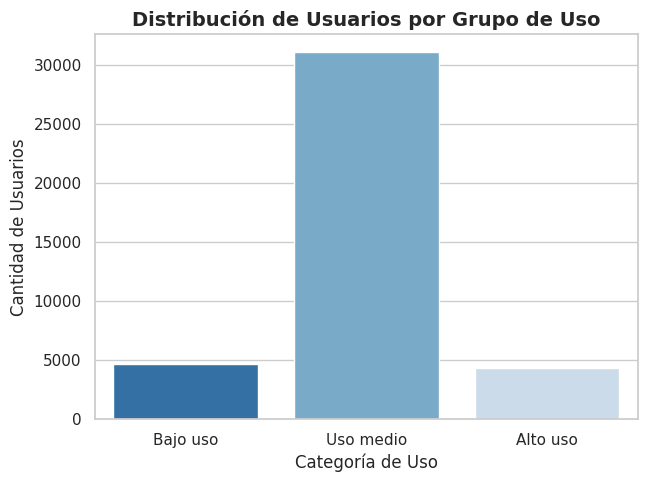

In [156]:
# Visualización de los segmentos por uso
#sns.countplot(...)

#plt.show()

# Configurar un estilo visual limpio
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICO 1: Distribución por Grupo de Uso
# ==========================================
plt.figure(figsize=(7, 5))


# Orden lógico para las categorías de uso
orden_uso = ["Bajo uso", "Uso medio", "Alto uso"]


# Crear el gráfico de barras contando las categorías de grupo_uso
sns.countplot(data=user_profile, x="grupo_uso", order=orden_uso, palette="Blues_r")

# Agregar título y etiquetas a los ejes
plt.title("Distribución de Usuarios por Grupo de Uso", fontsize=14, fontweight="bold")
plt.xlabel("Categoría de Uso", fontsize=12)
plt.ylabel("Cantidad de Usuarios", fontsize=12)

# Mostrar el gráfico
plt.show()


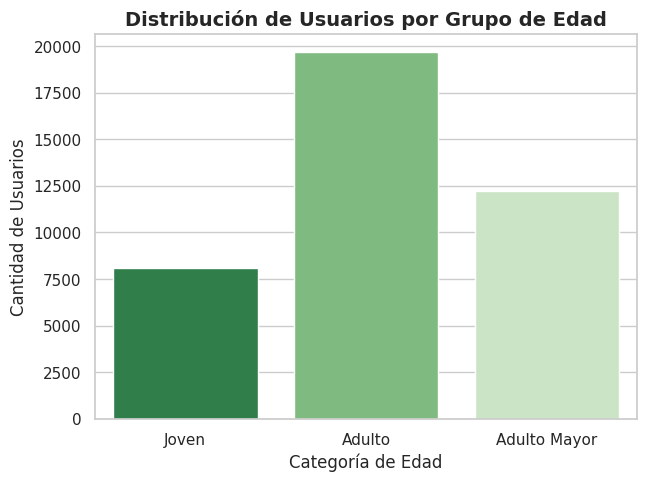

In [157]:
# Visualización de los segmentos por edad
# ==========================================
# GRÁFICO 2: Distribución por Grupo de Edad
# ==========================================
plt.figure(figsize=(7, 5))

# Orden lógico para las categorías de edad
orden_edad = ["Joven", "Adulto", "Adulto Mayor"]

# Crear el gráfico de barras contando las categorías de grupo_edad
sns.countplot(data=user_profile, x="grupo_edad", order=orden_edad, palette="Greens_r")

# Agregar título y etiquetas a los ejes
plt.title("Distribución de Usuarios por Grupo de Edad", fontsize=14, fontweight="bold")
plt.xlabel("Categoría de Edad", fontsize=12)
plt.ylabel("Cantidad de Usuarios", fontsize=12)

# Mostrar el gráfico
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
•	¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- En Users, proporción de valores nulos:
    city prop nulos: 11.725 %
    churn prop nulos: 88.35 %
 - En Usage, proporción de valores nulos:
    Date prop nulos: 0.125 %
    Duration prop nulos: 88.35 %
    Length nulos: 44.74 %
   
•	¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron tres grupos de clientes por edad: "Joven", "Adulto", "Adulto Mayor". Por nivel de uso se detectaron también tres grupos: "Alto uso", "Uso medio" y "Bajo uso".

•	¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los segmentos más valiosos son “Adulto” y “Uso Medio” porque son los que mayor cantidad de usuarios y tráfico tienen, respectivamente.

•	¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- La columna age tiene en valor mínimo -999, lo cual es un error que puede afectar las estadísticas de edad de los clientes
- 
•	¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Se tendría que realizar un análisis de los hallazgos encontrados comparándolos con el dataset “Plans” para conocer cuánto representa cada uno de los segmentos en pagos por mes. De acuerdo a esto se podrían crear planes más adecuados que reditúen más ganancias al negocio, así como un mejor valor y ser servicio al cliente.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
•	La columna “age” tiene en valor mínimo -999, lo cual es un error que puede afectar las estadísticas de edad de los clientes.
•	En Usage, se encontró un alto porcentaje de datos nulos en Duration: 88.35 % y  Length: 44.74 % Los cuales tienen relación con la columna Type, la cual hace referencia a Llamadas o mensajes de texto. Esto quiere decir que una llamada solo tiene duración y un mensaje de texto solo tiene longitud.

🔍 **Segmentos por Edad**
•	"Joven", 
•	"Adulto", 
•	"Adulto Mayor".

📊 **Segmentos por Nivel de Uso**
•	"Alto uso", 
•	"Uso medio" 
•	"Bajo uso"

➡️ Esto sugiere que ...


💡 **Recomendaciones**
Se recomienda realizar un cruce con el dataset “Plans” para conocer cuánto representa cada uno de los segmentos en pagos por mes. En base a los resultados se pueden crear nuevos planes mensuales que generen más ingresos al negocio y sean atractivos para los clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`